In [1]:
!unzip aggregated.zip

Archive:  aggregated.zip
   creating: sp26cai6108mle-project-aggregated/
   creating: sp26cai6108mle-project-aggregated/aggregated/
   creating: sp26cai6108mle-project-aggregated/aggregated/backpack/
  inflating: sp26cai6108mle-project-aggregated/aggregated/backpack/img1.png  
  inflating: sp26cai6108mle-project-aggregated/aggregated/backpack/img100.png  
  inflating: sp26cai6108mle-project-aggregated/aggregated/backpack/img102.png  
  inflating: sp26cai6108mle-project-aggregated/aggregated/backpack/img103.png  
  inflating: sp26cai6108mle-project-aggregated/aggregated/backpack/img104.png  
  inflating: sp26cai6108mle-project-aggregated/aggregated/backpack/img105.png  
  inflating: sp26cai6108mle-project-aggregated/aggregated/backpack/img106.png  
  inflating: sp26cai6108mle-project-aggregated/aggregated/backpack/img108.png  
  inflating: sp26cai6108mle-project-aggregated/aggregated/backpack/img109.png  
  inflating: sp26cai6108mle-project-aggregated/aggregated/backpack/img110.png  
  

In [2]:
!mv sp26cai6108mle-project-aggregated mle-aggregated

In [3]:
LABEL_ORDER = [
    "pen", "paper", "book", "clock", "phone", "laptop",
    "chair", "desk", "bottle", "keychain", "backpack", "calculator"
]

In [4]:
import torch

LABEL_TO_IDX = {label: i for i, label in enumerate(LABEL_ORDER)}

def folder_to_multihot(folder_name):
    labels = folder_name.split("_")
    target = torch.zeros(len(LABEL_ORDER), dtype=torch.float32)

    for label in labels:
        target[LABEL_TO_IDX[label]] = 1.0

    return target

In [5]:
from torchvision import transforms

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.15),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [6]:
from pathlib import Path
from PIL import Image
import torch
from torch.utils.data import Dataset

LABEL_ORDER = [
    "pen", "paper", "book", "clock", "phone", "laptop",
    "chair", "desk", "bottle", "keychain", "backpack", "calculator"
]
LABEL_TO_IDX = {label: i for i, label in enumerate(LABEL_ORDER)}
VALID_LABELS = set(LABEL_ORDER)

class MultiLabelFolderDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []

        for folder in self.root_dir.iterdir():
            if not folder.is_dir():
                continue

            labels = folder.name.split("_")

            # skip invalid folders
            if any(label not in VALID_LABELS for label in labels):
                continue
            if len(labels) != len(set(labels)):
                continue

            target = torch.zeros(len(LABEL_ORDER), dtype=torch.float32)
            for label in labels:
                target[LABEL_TO_IDX[label]] = 1.0

            for img_path in folder.glob("*.png"):
                self.samples.append((img_path, target.clone()))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, target = self.samples[idx]
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, target

In [7]:
from torch.utils.data import DataLoader, Subset
import torch

data_root = "/content/mle-aggregated/aggregated"

full_dataset = MultiLabelFolderDataset(data_root, transform=None)

n = len(full_dataset)
train_size = int(0.70 * n)
val_size = int(0.15 * n)
test_size = n - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_subset, val_subset, test_subset = torch.utils.data.random_split(
    range(n),
    [train_size, val_size, test_size],
    generator=generator
)

train_indices = train_subset.indices
val_indices = val_subset.indices
test_indices = test_subset.indices

train_dataset = Subset(
    MultiLabelFolderDataset(data_root, transform=train_transforms),
    train_indices
)

val_dataset = Subset(
    MultiLabelFolderDataset(data_root, transform=val_transforms),
    val_indices
)

test_dataset = Subset(
    MultiLabelFolderDataset(data_root, transform=val_transforms),
    test_indices
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=2)

print("Train size:", len(train_dataset))
print("Val size:", len(val_dataset))
print("Test size:", len(test_dataset))

Train size: 3180
Val size: 681
Test size: 682


In [8]:
img, target = train_dataset[0]
print(img.shape)      # should look like [3, 128, 128]
print(target.shape)   # should look like [12]
print(target)

torch.Size([3, 224, 224])
torch.Size([12])
tensor([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.])


In [9]:
import torch.nn as nn
from torchvision import models

model = models.resnet18(pretrained=True)
model.fc = nn.Linear(model.fc.in_features, 12)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 206MB/s]


In [10]:
criterion = nn.BCEWithLogitsLoss()

Saved best model at epoch 1
Epoch 1, Train Loss: 0.3352, Val Loss: 0.2031, Micro F1: 0.7315, Macro F1: 0.7333
Saved best model at epoch 2
Epoch 2, Train Loss: 0.1721, Val Loss: 0.1709, Micro F1: 0.7967, Macro F1: 0.7984
Saved best model at epoch 3
Epoch 3, Train Loss: 0.1314, Val Loss: 0.1552, Micro F1: 0.8018, Macro F1: 0.8004
Saved best model at epoch 4
Epoch 4, Train Loss: 0.1022, Val Loss: 0.1545, Micro F1: 0.8034, Macro F1: 0.8024
Saved best model at epoch 5
Epoch 5, Train Loss: 0.0820, Val Loss: 0.1415, Micro F1: 0.8221, Macro F1: 0.8217
Epoch 6, Train Loss: 0.0622, Val Loss: 0.1501, Micro F1: 0.8160, Macro F1: 0.8148
Epoch 7, Train Loss: 0.0512, Val Loss: 0.1441, Micro F1: 0.8207, Macro F1: 0.8206
Epoch 8, Train Loss: 0.0453, Val Loss: 0.1509, Micro F1: 0.8152, Macro F1: 0.8160
Epoch 9, Train Loss: 0.0376, Val Loss: 0.1450, Micro F1: 0.8333, Macro F1: 0.8329
Epoch 10, Train Loss: 0.0327, Val Loss: 0.1444, Micro F1: 0.8380, Macro F1: 0.8381
Epoch 11, Train Loss: 0.0271, Val Loss:

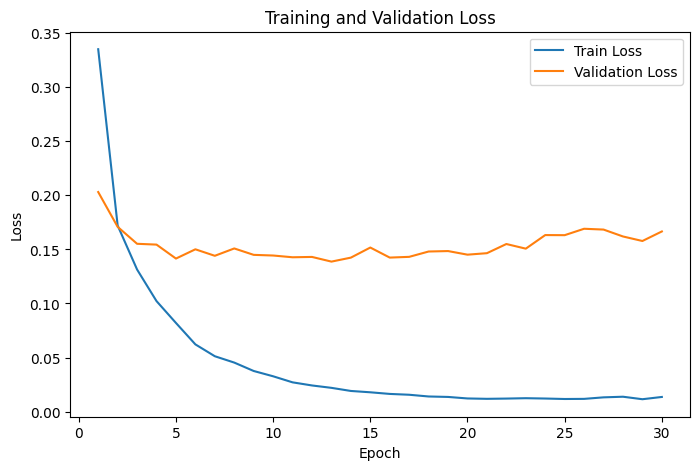

In [11]:
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
epochs = 30

train_losses = []
val_losses = []

best_val_loss = float("inf")
best_epoch = -1

for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).float()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    model.eval()
    val_loss = 0.0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device).float()

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            probs = torch.sigmoid(outputs)
            preds = (probs > 0.4).int()

            # force at least one prediction per image
            top_idx = torch.argmax(probs, dim=1)
            empty_rows = preds.sum(dim=1) == 0
            preds[empty_rows, top_idx[empty_rows]] = 1

            all_labels.append(labels.cpu().int())
            all_preds.append(preds.cpu())

    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    all_labels = torch.cat(all_labels).numpy()
    all_preds = torch.cat(all_preds).numpy()

    micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        best_epoch = epoch + 1
        torch.save(model.state_dict(), "best_model.pth")
        print(f"Saved best model at epoch {best_epoch}")

    print(
        f"Epoch {epoch+1}, "
        f"Train Loss: {avg_train_loss:.4f}, "
        f"Val Loss: {avg_val_loss:.4f}, "
        f"Micro F1: {micro_f1:.4f}, "
        f"Macro F1: {macro_f1:.4f}"
    )

print(f"Best epoch: {best_epoch}, Best Val Loss: {best_val_loss:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, epochs + 1), train_losses, label="Train Loss")
plt.plot(range(1, epochs + 1), val_losses, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

In [12]:
import numpy as np
import torch
from sklearn.metrics import f1_score

def find_best_thresholds(model, loader, device, num_classes=12):
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device).float()

            logits = model(images)
            probs = torch.sigmoid(logits)

            all_labels.append(labels.cpu())
            all_probs.append(probs.cpu())

    all_labels = torch.cat(all_labels).numpy()
    all_probs = torch.cat(all_probs).numpy()

    thresholds = []
    best_class_f1s = []

    for c in range(num_classes):
        best_t = 0.5
        best_f1 = -1.0

        for t in np.arange(0.1, 0.9, 0.05):
            preds = (all_probs[:, c] >= t).astype(int)
            f1 = f1_score(all_labels[:, c], preds, zero_division=0)

            if f1 > best_f1:
                best_f1 = f1
                best_t = float(t)

        thresholds.append(best_t)
        best_class_f1s.append(best_f1)

    return thresholds, best_class_f1s

In [13]:
best_thresholds, tuned_class_f1s = find_best_thresholds(
    model,
    val_loader,
    device,
    num_classes=len(LABEL_ORDER)
)

print("Best thresholds:", best_thresholds)
print("Best per-class F1 during search:", tuned_class_f1s)

Best thresholds: [0.15000000000000002, 0.20000000000000004, 0.5000000000000001, 0.7500000000000002, 0.25000000000000006, 0.45000000000000007, 0.25000000000000006, 0.5000000000000001, 0.7500000000000002, 0.5000000000000001, 0.15000000000000002, 0.45000000000000007]
Best per-class F1 during search: [0.7857142857142857, 0.8776371308016878, 0.7253886010362695, 0.8658536585365854, 0.7757009345794392, 0.8341708542713567, 0.8787878787878788, 0.8104575163398693, 0.8390243902439024, 0.8176100628930818, 0.9494949494949495, 0.896551724137931]


In [14]:
torch.save(model.state_dict(), "resnet_mle.pth")

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

per_class_precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
per_class_recall = recall_score(all_labels, all_preds, average=None, zero_division=0)
per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

for i, name in enumerate(LABEL_ORDER):
    print(
        f"{name:12s} | "
        f"Precision: {per_class_precision[i]:.4f} | "
        f"Recall: {per_class_recall[i]:.4f} | "
        f"F1: {per_class_f1[i]:.4f}"
    )

pen          | Precision: 0.8602 | Recall: 0.6780 | F1: 0.7583
paper        | Precision: 0.8829 | Recall: 0.8376 | F1: 0.8596
book         | Precision: 0.7802 | Recall: 0.6698 | F1: 0.7208
clock        | Precision: 0.8132 | Recall: 0.8605 | F1: 0.8362
phone        | Precision: 0.8041 | Recall: 0.7222 | F1: 0.7610
laptop       | Precision: 0.8350 | Recall: 0.8269 | F1: 0.8309
chair        | Precision: 0.8842 | Recall: 0.8571 | F1: 0.8705
desk         | Precision: 0.7750 | Recall: 0.7949 | F1: 0.7848
bottle       | Precision: 0.7619 | Recall: 0.9057 | F1: 0.8276
keychain     | Precision: 0.7976 | Recall: 0.8171 | F1: 0.8072
backpack     | Precision: 0.9670 | Recall: 0.8980 | F1: 0.9312
calculator   | Precision: 0.9192 | Recall: 0.8585 | F1: 0.8878


In [16]:
from sklearn.metrics import f1_score, precision_score, recall_score

model.eval()
all_labels = []
all_preds = []
all_probs = []

thresholds_tensor = torch.tensor(best_thresholds, dtype=torch.float32).view(1, -1).to(device)

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        labels = labels.to(device).float()

        logits = model(images)
        probs = torch.sigmoid(logits)
        preds = (probs >= thresholds_tensor).int()

        all_labels.append(labels.cpu().int())
        all_preds.append(preds.cpu())
        all_probs.append(probs.cpu())

all_labels = torch.cat(all_labels).numpy()
all_preds = torch.cat(all_preds).numpy()
all_probs = torch.cat(all_probs).numpy()

micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

print(f"Tuned-threshold Micro F1: {micro_f1:.4f}")
print(f"Tuned-threshold Macro F1: {macro_f1:.4f}")

per_class_precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
per_class_recall = recall_score(all_labels, all_preds, average=None, zero_division=0)
per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

for i, name in enumerate(LABEL_ORDER):
    print(
        f"{name:12s} | "
        f"Threshold: {best_thresholds[i]:.2f} | "
        f"Precision: {per_class_precision[i]:.4f} | "
        f"Recall: {per_class_recall[i]:.4f} | "
        f"F1: {per_class_f1[i]:.4f}"
    )

Tuned-threshold Micro F1: 0.8385
Tuned-threshold Macro F1: 0.8380
pen          | Threshold: 0.15 | Precision: 0.8302 | Recall: 0.7458 | F1: 0.7857
paper        | Threshold: 0.20 | Precision: 0.8667 | Recall: 0.8889 | F1: 0.8776
book         | Threshold: 0.50 | Precision: 0.8046 | Recall: 0.6604 | F1: 0.7254
clock        | Threshold: 0.75 | Precision: 0.9103 | Recall: 0.8256 | F1: 0.8659
phone        | Threshold: 0.25 | Precision: 0.7830 | Recall: 0.7685 | F1: 0.7757
laptop       | Threshold: 0.45 | Precision: 0.8737 | Recall: 0.7981 | F1: 0.8342
chair        | Threshold: 0.25 | Precision: 0.8700 | Recall: 0.8878 | F1: 0.8788
desk         | Threshold: 0.50 | Precision: 0.8267 | Recall: 0.7949 | F1: 0.8105
bottle       | Threshold: 0.75 | Precision: 0.8687 | Recall: 0.8113 | F1: 0.8390
keychain     | Threshold: 0.50 | Precision: 0.8442 | Recall: 0.7927 | F1: 0.8176
backpack     | Threshold: 0.15 | Precision: 0.9400 | Recall: 0.9592 | F1: 0.9495
calculator   | Threshold: 0.45 | Precision:

In [17]:
from sklearn.metrics import f1_score, precision_score, recall_score
import torch

model.eval()
all_labels = []
all_preds = []

thresholds_tensor = torch.tensor(best_thresholds, dtype=torch.float32).view(1, -1).to(device)

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).float()

        logits = model(images)
        probs = torch.sigmoid(logits)
        preds = (probs >= thresholds_tensor).int()

        all_labels.append(labels.cpu().int())
        all_preds.append(preds.cpu())

all_labels = torch.cat(all_labels).numpy()
all_preds = torch.cat(all_preds).numpy()

micro_f1 = f1_score(all_labels, all_preds, average="micro", zero_division=0)
macro_f1 = f1_score(all_labels, all_preds, average="macro", zero_division=0)

print(f"Test Micro F1: {micro_f1:.4f}")
print(f"Test Macro F1: {macro_f1:.4f}")

per_class_precision = precision_score(all_labels, all_preds, average=None, zero_division=0)
per_class_recall = recall_score(all_labels, all_preds, average=None, zero_division=0)
per_class_f1 = f1_score(all_labels, all_preds, average=None, zero_division=0)

for i, name in enumerate(LABEL_ORDER):
    print(
        f"{name:12s} | "
        f"Precision: {per_class_precision[i]:.4f} | "
        f"Recall: {per_class_recall[i]:.4f} | "
        f"F1: {per_class_f1[i]:.4f}"
    )

Test Micro F1: 0.8297
Test Macro F1: 0.8318
pen          | Precision: 0.8411 | Recall: 0.7258 | F1: 0.7792
paper        | Precision: 0.8163 | Recall: 0.8000 | F1: 0.8081
book         | Precision: 0.8387 | Recall: 0.6783 | F1: 0.7500
clock        | Precision: 1.0000 | Recall: 0.7308 | F1: 0.8444
phone        | Precision: 0.8103 | Recall: 0.8468 | F1: 0.8282
laptop       | Precision: 0.8265 | Recall: 0.7788 | F1: 0.8020
chair        | Precision: 0.8211 | Recall: 0.8966 | F1: 0.8571
desk         | Precision: 0.8539 | Recall: 0.8736 | F1: 0.8636
bottle       | Precision: 0.8889 | Recall: 0.7928 | F1: 0.8381
keychain     | Precision: 0.7952 | Recall: 0.7674 | F1: 0.7811
backpack     | Precision: 0.9451 | Recall: 0.9451 | F1: 0.9451
calculator   | Precision: 0.9167 | Recall: 0.8544 | F1: 0.8844


**Shared Prediction Logic**

In [ ]:
def get_probabilities(batch_images):
    model.eval()
    with torch.no_grad():
        logits = model(batch_images.to(device))
        probs = torch.sigmoid(logits).cpu()
    return probs

**Grad CAM**

In [18]:
!pip -q install grad-cam


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 115.4 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [19]:
# Citation: https://arxiv.org/pdf/1610.02391
# https://github.com/jacobgil/pytorch-grad-cam GradCam Github REPO

import numpy as np
import matplotlib.pyplot as plt
import torch

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ResNet target layer
target_layers = [model.layer4[-1]]

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def unnormalize_image(img_tensor):
    img = img_tensor.detach().cpu() * std + mean
    img = img.permute(1, 2, 0).numpy()
    return np.clip(img, 0, 1)

def get_batch_predictions(batch_images, threshold=0.4, thresholds=None):
    probs = get_probabilities(batch_images)

    if thresholds is not None:
        thresholds_tensor = torch.tensor(thresholds, dtype=torch.float32).view(1, -1)
        preds = (probs >= thresholds_tensor).int()
    else:
        preds = (probs >= threshold).int()

    return probs, preds

def labels_from_multihot(multihot, class_names=LABEL_ORDER):
    return [class_names[i] for i, v in enumerate(multihot) if int(v) == 1]

def show_gradcam_for_class(image_tensor, class_idx, alpha=0.5):
    cam = GradCAM(model=model, target_layers=target_layers)
    input_tensor = image_tensor.unsqueeze(0).to(device)
    targets = [ClassifierOutputTarget(class_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    rgb_img = unnormalize_image(image_tensor)
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True, image_weight=alpha)
    return rgb_img, visualization

def show_example_with_gradcam(batch_images, batch_labels, image_index=0, class_idx=None, threshold=0.4, thresholds=None):
    probs, preds = get_batch_predictions(batch_images, threshold=threshold, thresholds=thresholds)

    image_tensor = batch_images[image_index].cpu()
    true_labels = labels_from_multihot(batch_labels[image_index].cpu())
    pred_labels = labels_from_multihot(preds[image_index])

    if class_idx is None:
        class_idx = int(torch.argmax(probs[image_index]).item())

    rgb_img, visualization = show_gradcam_for_class(image_tensor, class_idx)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img)
    plt.axis('off')
    plt.title(f'Original\nTrue: {true_labels}\nPred: {pred_labels}')

    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.axis('off')
    plt.title(f'Grad-CAM for {LABEL_ORDER[class_idx]}\nProb: {probs[image_index][class_idx]:.3f}')

    plt.tight_layout()
    plt.show()

    return probs[image_index], preds[image_index]

def show_all_predicted_gradcams(batch_images, batch_labels, image_index=0, threshold=0.4, thresholds=None):
    probs, preds = get_batch_predictions(batch_images, threshold=threshold, thresholds=thresholds)
    image_tensor = batch_images[image_index].cpu()
    true_labels = labels_from_multihot(batch_labels[image_index].cpu())
    pred_class_indices = [i for i, v in enumerate(preds[image_index]) if int(v) == 1]
    rgb_img = unnormalize_image(image_tensor)

    if len(pred_class_indices) == 0:
        print('No predicted labels above threshold for this image.')
        plt.figure(figsize=(4, 4))
        plt.imshow(rgb_img)
        plt.axis('off')
        plt.title(f'True: {true_labels}')
        plt.show()
        return

    fig, axes = plt.subplots(1, len(pred_class_indices) + 1, figsize=(5 * (len(pred_class_indices) + 1), 5))
    axes[0].imshow(rgb_img)
    axes[0].axis('off')
    axes[0].set_title(f'Original\nTrue: {true_labels}')

    for ax, class_idx in zip(axes[1:], pred_class_indices):
        _, visualization = show_gradcam_for_class(image_tensor, class_idx)
        ax.imshow(visualization)
        ax.axis('off')
        ax.set_title(f'{LABEL_ORDER[class_idx]}\nProb: {probs[image_index][class_idx]:.3f}')

    plt.tight_layout()
    plt.show()


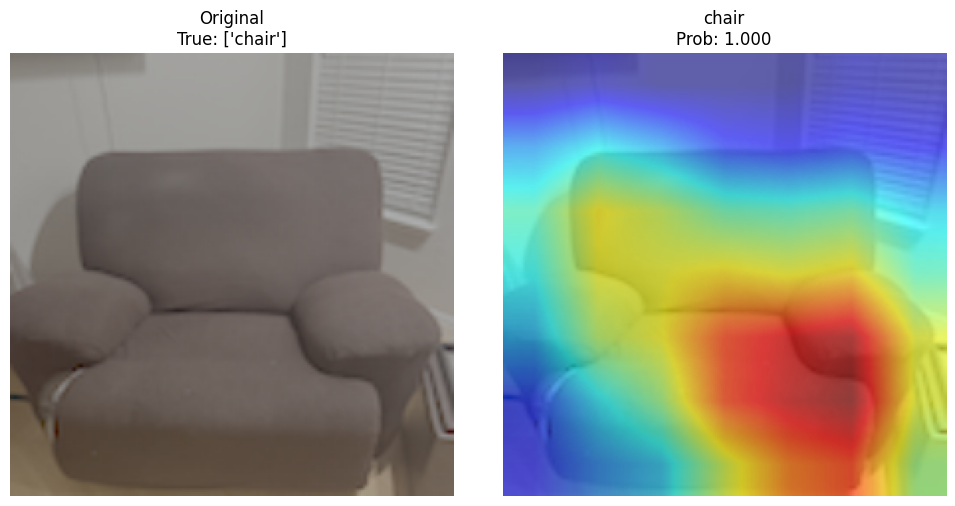

In [20]:
batch_images, batch_labels = next(iter(val_loader))

show_all_predicted_gradcams(
    batch_images,
    batch_labels,
    image_index=5,
    thresholds=best_thresholds if "best_thresholds" in globals() else None
)

**LIME**

In [21]:
!pip install lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 22.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=dabbb13a2d0ad96cb1867d5f29e4d629928ec77ae77d1a6788c49e4b3049f4bf
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime


In [22]:
import numpy as np
import torch

def predict_fn(images_np, model, device):
    model.eval()

    # LIME passes images as (N, H, W, C)
    images_np = np.array(images_np, dtype=np.float32)

    # scale to 0-1
    if images_np.max() > 1.0:
        images_np = images_np / 255.0

    # Convert to tensor and change to (N, C, H, W)
    images_tensor = torch.tensor(images_np, dtype=torch.float32).permute(0, 3, 1, 2)

    # Normalize the same way inputs were normalized
    mean = torch.tensor([0.485, 0.456, 0.406], dtype=torch.float32).view(1, 3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], dtype=torch.float32).view(1, 3, 1, 1)
    images_tensor = (images_tensor - mean) / std

    images_tensor = images_tensor.to(device)

    with torch.no_grad():
        logits = model(images_tensor)
        probs = torch.sigmoid(logits)

    return probs.cpu().numpy()

In [23]:
# Citation:
# https://arxiv.org/abs/1602.04938
# https://github.com/marcotcr/lime

from lime import lime_image

def explain_with_lime(image_np, model, device, class_names, target_class_idx):
    explainer = lime_image.LimeImageExplainer()

    explanation = explainer.explain_instance(
        image=image_np,
        classifier_fn=lambda x: predict_fn(x, model, device),
        top_labels=None,
        labels=(target_class_idx,),
        hide_color=0,
        num_samples=1000
    )

    temp, mask = explanation.get_image_and_mask(
        label=target_class_idx,
        positive_only=True,
        num_features=5,
        hide_rest=False
    )

    return temp, mask

In [27]:
# Citation:
# https://arxiv.org/abs/1602.04938
# https://github.com/marcotcr/lime

import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries

def show_lime_explanation(image_np, temp, mask, class_name):
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(image_np)
    plt.axis("off")
    plt.title("Original Image")

    plt.subplot(1, 2, 2)
    plt.imshow(mark_boundaries(temp, mask))
    plt.axis("off")
    plt.title(f"LIME for {class_name}")

    plt.tight_layout()
    plt.show()

In [37]:
probs, preds = get_batch_predictions(batch_images)
img = 4
class_idx = int(torch.argmax(probs[img]).item())

image_tensor = batch_images[img].cpu()
image_np = unnormalize_image(image_tensor)

temp, mask = explain_with_lime(
    image_np=image_np,
    model=model,
    device=device,
    class_names=LABEL_ORDER,
    target_class_idx=class_idx
)

  0%|          | 0/1000 [00:00<?, ?it/s]

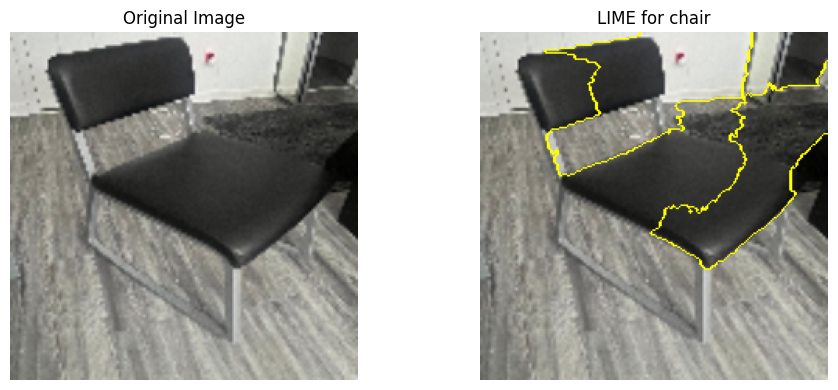

In [38]:
show_lime_explanation(image_np, temp, mask, LABEL_ORDER[class_idx])